# Momentum Factor Evaluation
Analysis of the classic Momentum factor alongside Fama-French baseline factors.
This notebook:
- Downloads official Fama-French data
- Visualizes cumulative performance (Matplotlib + interactive Plotly version below)
- Computes performance metrics
- Builds the classic 12-1 momentum signal
**All parameters are configurable at the top** (time ranges, lookback, tickers, etc.).

## 🔧 Configuration Parameters
**Data Sources & Time Ranges** (easy to change):
- **Fama-French Factors**: Monthly data from Ken French library (1963–present)
- 5-Factor model (Mkt-RF, HML, RMW, CMA)
- Momentum factor (WML = Winner minus Loser)
- **SPY Momentum Example**: Daily adjusted close from Yahoo Finance
- **Time Range for SPY**: 2000-01-01 → present (change `SPY_START_DATE` below)
- **Momentum Parameters**: 12-month formation period + 1-month skip (standard academic definition)
- **Annualization**: 12 (monthly factors)
Modify any value below and re-run the notebook.
 ==================== CONFIGURATION PARAMETERS ====================

In [1]:
# %pip install yfinance 
# %pip install plotly

In [2]:
SPY_START_DATE = "2000-01-01"          # Change time range for SPY example
MOMENTUM_LOOKBACK_MONTHS = 12          # Formation period (standard = 12)
MOMENTUM_SKIP_MONTHS = 1               # Skip period to avoid short-term reversal (standard = 1)
ANNUALIZATION_FACTOR = 12              # Monthly → annual
FF_START_YEAR = 1963                   # Fama-French data starts automatically here
TICKER_FOR_EXAMPLE = "SPY"             # Change to any ticker (e.g. "AAPL", "^GSPC")

# Data description (for reference)
DATA_DESCRIPTION = """
- Fama-French 5 Factors + Momentum (WML) from mba.tuck.dartmouth.edu
- SPY adjusted close from Yahoo Finance (yfinance)
"""

print("✅ Parameters loaded:")
print(f"   • SPY time range: {SPY_START_DATE} → present")
print(f"   • Momentum lookback: {MOMENTUM_LOOKBACK_MONTHS} months (skip {MOMENTUM_SKIP_MONTHS})")
print(f"   • Ticker: {TICKER_FOR_EXAMPLE}")
print(f"   • Data included: {DATA_DESCRIPTION.strip()}")

✅ Parameters loaded:
   • SPY time range: 2000-01-01 → present
   • Momentum lookback: 12 months (skip 1)
   • Ticker: SPY
   • Data included: - Fama-French 5 Factors + Momentum (WML) from mba.tuck.dartmouth.edu
- SPY adjusted close from Yahoo Finance (yfinance)


## 1. Import Libraries

In [3]:
import requests
import zipfile
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import plotly.graph_objects as go   # ← NEW: for the identical interactive plot

## 2. Robust Fama-French Data Downloader
(Handles all previous errors automatically)

In [4]:
def get_ff_data(url: str, skiprows: int = 3, mom_col: str = None) -> pd.DataFrame:
    response = requests.get(url)
    response.raise_for_status()
    
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        csv_files = [name for name in z.namelist() if name.lower().endswith(('.csv', '.CSV'))]
        zip_filename = csv_files[0]
        print(f"✅ Using file inside ZIP: {zip_filename}")
        
        with z.open(zip_filename) as f:
            raw_text = f.read().decode('utf-8')
    
    df = pd.read_csv(io.StringIO(raw_text), skiprows=skiprows, index_col=0, na_values=[-99.99, -999])
    
    # Robust cleaning
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna(how='all')
    df.index = df.index.astype(str).str.strip()
    df = df[df.index.str.match(r'^\d{6}$')]
    
    print(f"✅ Cleaned data: {len(df)} monthly rows")
    
    df.index = pd.to_datetime(df.index + '01', format='%Y%m%d')
    df = df / 100.0
    
    if mom_col and mom_col in df.columns:
        df = df.rename(columns={mom_col: 'WML'})
    elif mom_col and len(df.columns) == 1:
        df.columns = ['WML']
    
    return df

## 3. Download & combine factors

The next cell downloads Ken French’s **monthly** factor ZIPs from Tuck, reads the CSV inside each archive, cleans rows to valid `YYYYMM` dates, converts the index to month-end timestamps, and **divides by 100** so returns are in **decimal** form (e.g. `0.05` ≈ 5% per month).

It then **inner-joins** the Fama–French **5-factor (2×3)** dataset with the **momentum** file so every row has both blocks, and keeps **`Mkt-RF` … `WML`** (dropping `RF` and any incomplete rows).

### What each column means

| Column | Short name | Meaning |
|--------|------------|---------|
| **Mkt-RF** | Market minus RF | Broad US equity market return **minus** the risk-free rate (equity risk premium). |
| **SMB** | Small minus big | **Size**: small-cap portfolio minus large-cap portfolio. |
| **HML** | High minus low | **Value vs growth**: high book-to-market (“value”) minus low book-to-market (“growth”). |
| **RMW** | Robust minus weak | **Profitability**: strong operating profitability minus weak profitability (FF5). |
| **CMA** | Conservative minus aggressive | **Investment**: low asset growth (“conservative”) minus high asset growth (“aggressive”) (FF5). |
| **WML** | Winners minus losers | **Momentum**: past winners minus past losers (here from French’s momentum file; often labeled `Mom` in the raw CSV). |

**Mkt-RF … CMA** are the **Fama–French (2015) five factors**. **WML** is the **Carhart-style momentum** factor. Research often uses **five factors + momentum** together; momentum is **not** part of the original FF5 definition.


In [ ]:
print("Downloading Fama-French factors...")

url_5f = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip"
ff5 = get_ff_data(url_5f, skiprows=3)
print(ff5.head())

url_mom = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Momentum_Factor_CSV.zip"
mom = get_ff_data(url_mom, skiprows=13, mom_col="Mom")
print(mom.head())

factors = ff5.join(mom[['WML']], how='inner')

data = factors[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'WML']].dropna()

print(f"✅ Final data range: {data.index.min().date()} – {data.index.max().date()}")

print(data.shape)

print("\n=== Initial Factor Data (Head) ===")
data.head()


✅ Using file inside ZIP: F-F_Research_Data_5_Factors_2x3.csv
✅ Cleaned data: 753 monthly rows
            Mkt-RF     SMB     HML     RMW     CMA      RF
1963-07-01 -0.0039 -0.0048 -0.0081  0.0064 -0.0115  0.0027
1963-08-01  0.0508 -0.0080  0.0170  0.0040 -0.0038  0.0025
1963-09-01 -0.0157 -0.0043  0.0000 -0.0078  0.0015  0.0027
1963-10-01  0.0254 -0.0134 -0.0004  0.0279 -0.0225  0.0029
1963-11-01 -0.0086 -0.0085  0.0173 -0.0043  0.0227  0.0027
✅ Using file inside ZIP: F-F_Momentum_Factor.csv
✅ Cleaned data: 1191 monthly rows
               WML
1927-01-01  0.0057
1927-02-01 -0.0150
1927-03-01  0.0352
1927-04-01  0.0436
1927-05-01  0.0278
✅ Final data range: 1963-07-01 – 2026-03-01
(753, 6)

=== Initial Factor Data (Head) ===


,Mkt-RF,SMB,HML,RMW,CMA,WML
1963-07-01,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0101
1963-08-01,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0100
1963-09-01,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0012
1963-10-01,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0313
1963-11-01,-0.0086,-0.0085,0.0173,-0.0043,0.0227,-0.0078


## 4. Cumulative Performance of Alpha Factors (Matplotlib)

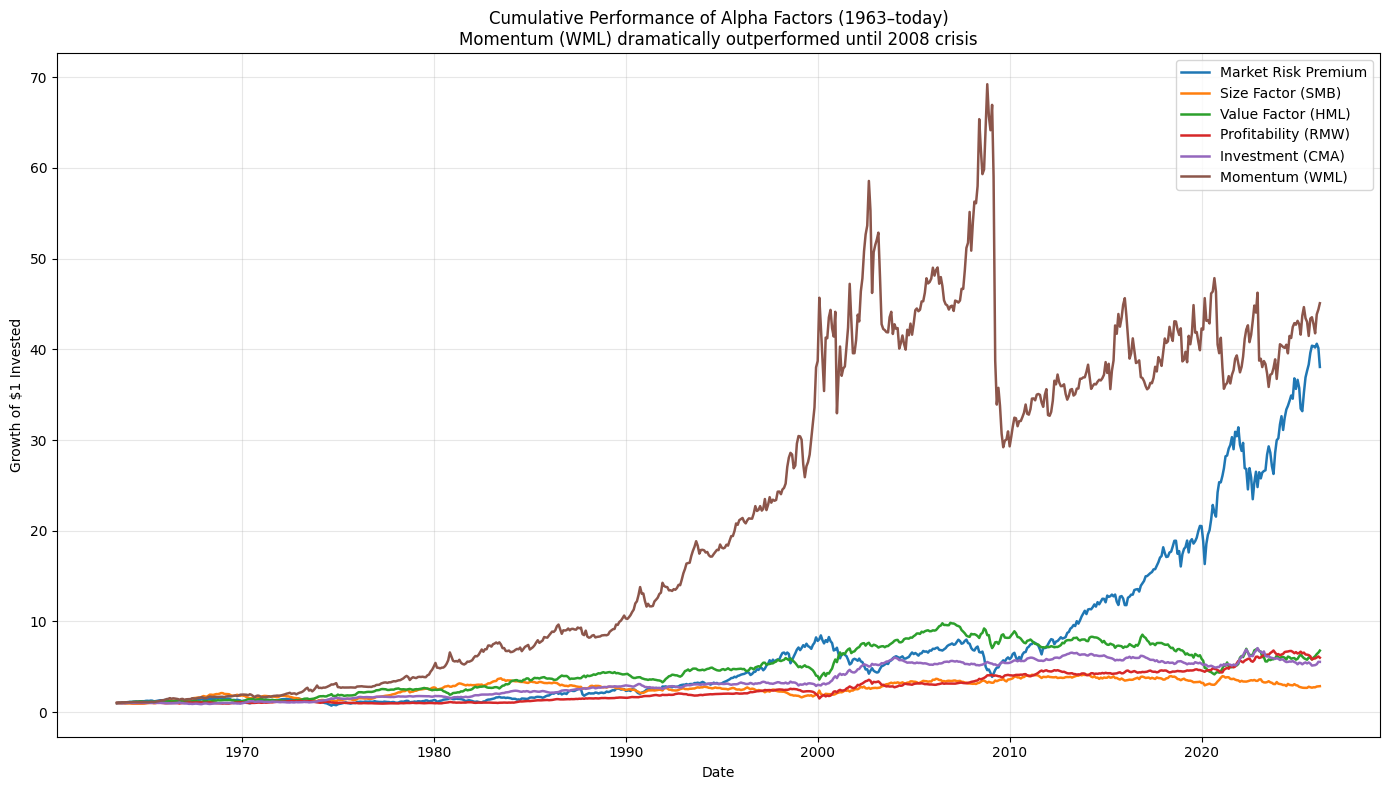

In [6]:
cum_ret = (1 + data).cumprod()

factor_names = {
    'Mkt-RF': 'Market Risk Premium',
    'SMB': 'Size Factor (SMB)',
    'HML': 'Value Factor (HML)',
    'RMW': 'Profitability (RMW)',
    'CMA': 'Investment (CMA)',
    'WML': 'Momentum (WML)'
}

plt.figure(figsize=(14, 8))
for col in data.columns:
    plt.plot(cum_ret.index, cum_ret[col], label=factor_names.get(col, col), linewidth=1.8)
plt.title("Cumulative Performance of Alpha Factors (1963–today)\n"
          "Momentum (WML) dramatically outperformed until 2008 crisis")
plt.ylabel("Growth of $1 Invested")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4b. **Identical Interactive Plotly Version** (NEW)
Same exact data, same title, same lines — but **fully interactive** (hover tooltips, zoom, pan, legend toggle).
Perfect for presentations or deeper exploration.

In [7]:
fig = go.Figure()

for col in data.columns:
    fig.add_trace(go.Scatter(
        x=cum_ret.index,
        y=cum_ret[col],
        name=factor_names.get(col, col),
        mode='lines',
        line=dict(width=1.8),
        hovertemplate='%{y:.4f}<extra></extra>'
    ))

fig.update_layout(
    title="Cumulative Performance of Alpha Factors (1963–today)<br>"
          "Momentum (WML) dramatically outperformed until 2008 crisis",
    xaxis_title="Date",
    yaxis_title="Growth of $1 Invested",
    legend_title="Factor",
    template="plotly_white",
    height=600,
    width=1000,
    hovermode="x unified"
)

fig.update_xaxes(showgrid=True)
fig.update_yaxes(showgrid=True)
fig.show()

## 5. Performance metrics

The next cell defines **`evaluate_factors`**, which summarizes each factor column in `data` (monthly **decimal** returns, same scale as after ÷100 in §3).

### What the function computes (per factor)

| Output | Formula (intuition) |
|--------|----------------------|
| **Ann. Return (%)** | `mean(monthly return) × annualization` → treated as a simple **arithmetic** annualized mean (here `annualization` = `ANNUALIZATION_FACTOR`, 12 for monthly data). Shown as a **percentage**. |
| **Ann. Vol (%)** | `std(monthly return) × √annualization` → monthly volatility scaled to an **annual** figure (classic √12 rule for i.i.d.-style scaling). Shown as a **percentage**. |
| **Sharpe** | `Ann. Return / Ann. Vol` (with a guard if vol is 0). This is a **compact Sharpe-style ratio** on the factor series itself: it does **not** subtract a separate risk-free rate in the numerator, because several series (e.g. **Mkt-RF**) are already **excess** of the risk-free rate by construction. |
| **Max DD (%)** | Builds **cumulative wealth** `cum = (1 + r).cumprod()`, then running drawdown `(cum / cum.cummax()) - 1`, and takes the **minimum** (largest peak-to-trough loss). Reported as a **percentage**. |

The function stores those four numbers per column, then returns **`pd.DataFrame(metrics).T`** so each **row** is a factor and each **column** is a metric. The notebook then shows that table with a **pandas `Styler`**: consistent **two-decimal** formatting, a short **caption**, and **background gradients** on **Sharpe** and **Max DD** so you can scan risk/return across factors quickly.

### Correlation block

The code builds **`data.corr()`** (Pearson) and draws a **heatmap** (diverging colormap, −1 to 1) with **annotated** cells so co-movement is easier to scan than a raw matrix. **1** / **−1** = strong linear co-movement; **0** ≈ none.


### Factor performance metrics

,Ann. Return (%),Ann. Vol (%),Sharpe,Max DD (%)
Mkt-RF,7.02,15.44,0.45,-55.75
SMB,2.22,10.47,0.21,-56.47
HML,3.58,10.29,0.35,-57.79
RMW,3.16,7.70,0.41,-41.78
CMA,2.98,7.16,0.42,-27.31
WML,7.17,14.44,0.50,-57.82


### Factor return correlations (Pearson)

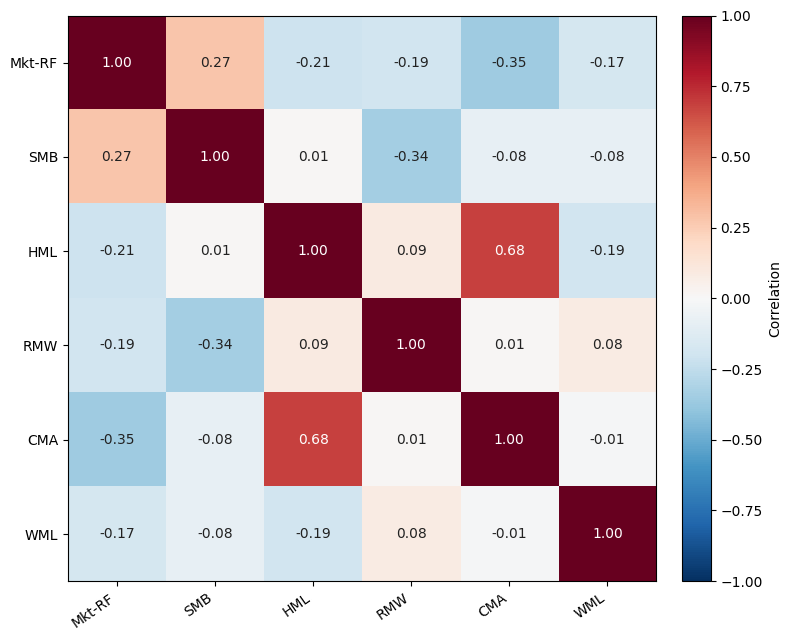

In [12]:
from IPython.display import Markdown, display


def evaluate_factors(returns: pd.DataFrame, annualization: int = ANNUALIZATION_FACTOR):
    """Return one row per factor; numeric values (styler handles rounding)."""
    metrics = {}
    for col in returns.columns:
        r = returns[col]
        ann_ret = r.mean() * annualization
        ann_vol = r.std() * np.sqrt(annualization)
        sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan
        cum = (1 + r).cumprod()
        max_dd = ((cum / cum.cummax()) - 1).min()
        metrics[col] = {
            "Ann. Return (%)": ann_ret * 100,
            "Ann. Vol (%)": ann_vol * 100,
            "Sharpe": sharpe,
            "Max DD (%)": max_dd * 100,
        }
    return pd.DataFrame(metrics).T


metrics_df = evaluate_factors(data)

display(Markdown("### Factor performance metrics"))
display(
    metrics_df.style.format("{:.2f}")
    .set_caption(
        "Annualization = 12 (monthly data). Sharpe = ann. mean return ÷ ann. vol. "
        "Max DD = worst peak-to-trough loss on (1+r).cumprod()."
    )
    .background_gradient(axis=None, subset=["Sharpe"], cmap="YlGn")
    .background_gradient(axis=None, subset=["Max DD (%)"], cmap="Reds")
)

corr = data.corr()
display(Markdown("### Factor return correlations (Pearson)"))

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=35, ha="right")
ax.set_yticklabels(corr.index)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        val = corr.iloc[i, j]
        ax.text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=10,
            color="white" if abs(val) > 0.55 else "#222",
        )
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Correlation")
plt.tight_layout()
plt.show()


## 6. Classic 12-1 Month Momentum Signal
(Uses parameters from top of notebook)


✅ SPY data loaded: 6630 days

Latest 12-1 Momentum signal for SPY:
Date
2026-04-30 00:00:00-04:00    0.183809
2026-05-01 00:00:00-04:00    0.184775
2026-05-04 00:00:00-04:00    0.182502
2026-05-05 00:00:00-04:00    0.180620
2026-05-06 00:00:00-04:00    0.242364
2026-05-07 00:00:00-04:00    0.353229
2026-05-08 00:00:00-04:00    0.363464
2026-05-11 00:00:00-04:00    0.384243
2026-05-12 00:00:00-04:00    0.264929
2026-05-13 00:00:00-04:00    0.339016
Name: Close, dtype: float64


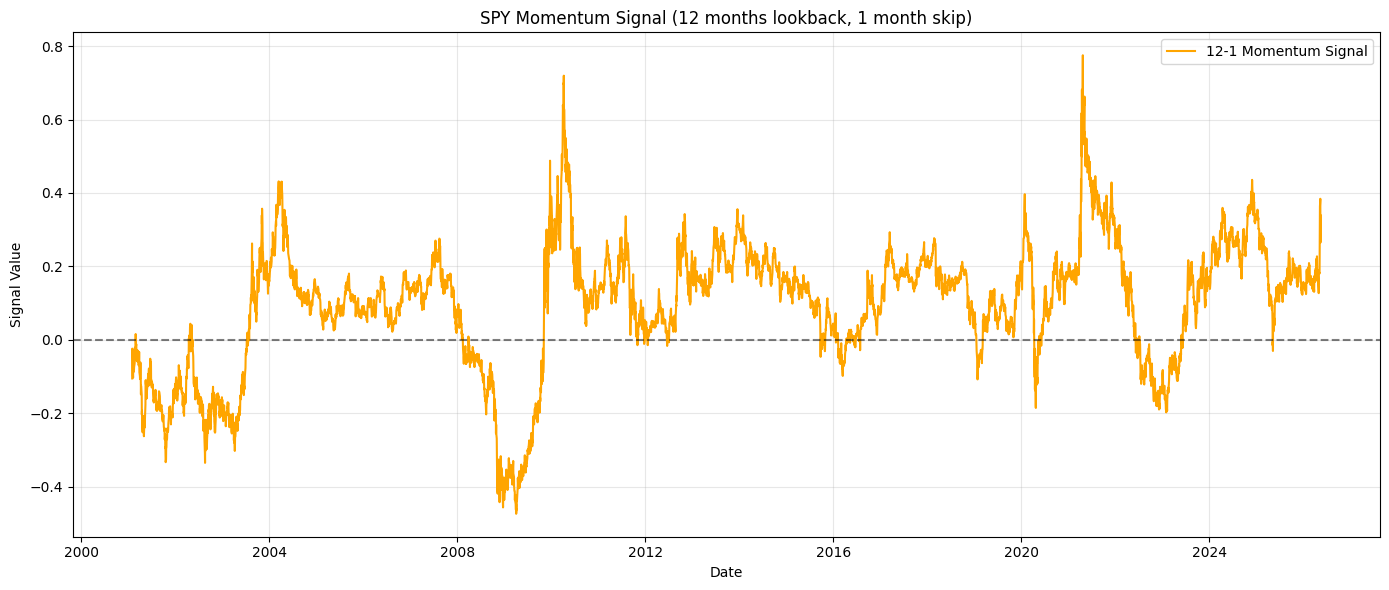

In [9]:
print(f"\nDownloading {TICKER_FOR_EXAMPLE} data for momentum example...")
ticker = yf.Ticker(TICKER_FOR_EXAMPLE)
prices = ticker.history(start=SPY_START_DATE, auto_adjust=True)['Close']

print(f"✅ {TICKER_FOR_EXAMPLE} data loaded: {len(prices)} days")

def momentum_signal(prices: pd.Series, months: int = MOMENTUM_LOOKBACK_MONTHS, skip: int = MOMENTUM_SKIP_MONTHS):
    return prices.pct_change(periods=months * 21).shift(skip * 21)

mom_sig = momentum_signal(prices)

print(f"\nLatest {MOMENTUM_LOOKBACK_MONTHS}-{MOMENTUM_SKIP_MONTHS} Momentum signal for {TICKER_FOR_EXAMPLE}:")
print(mom_sig.tail(10))

# Matplotlib Version
plt.figure(figsize=(14, 6))
plt.plot(mom_sig.index, mom_sig, label=f"{MOMENTUM_LOOKBACK_MONTHS}-{MOMENTUM_SKIP_MONTHS} Momentum Signal", color="orange")
plt.title(f"{TICKER_FOR_EXAMPLE} Momentum Signal ({MOMENTUM_LOOKBACK_MONTHS} months lookback, {MOMENTUM_SKIP_MONTHS} month skip)")
plt.ylabel("Signal Value")
plt.xlabel("Date")
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Interactive Plotly Version
fig_mom = go.Figure()
fig_mom.add_trace(go.Scatter(
    x=mom_sig.index,
    y=mom_sig,
    name="Momentum Signal",
    mode='lines',
    line={'color': 'orange', 'width': 1.5},
    hovertemplate='%{y:.4f}<extra></extra>'
))

fig_mom.update_layout(
    title=f"{TICKER_FOR_EXAMPLE} Momentum Signal ({MOMENTUM_LOOKBACK_MONTHS}m lookback, {MOMENTUM_SKIP_MONTHS}m skip)",
    xaxis_title="Date",
    yaxis_title="Signal Value",
    template="plotly_white",
    height=500,
    width=1000,
    hovermode="x unified"
)
fig_mom.add_hline(y=0, line_dash="dash", line_color="black", opacity=0.5)
fig_mom.update_xaxes(showgrid=True)
fig_mom.update_yaxes(showgrid=True)
fig_mom.show()

## ✅ Notebook Complete!
You can now:
- Change any parameter at the top
- Re-run all cells
- Use the **interactive Plotly chart** for exploration
- Integrate alternative data (e.g., sentiment or macroeconomic indicators) into the momentum signal
Everything is fully explained and configurable.
Happy factor research! 🚀

### **Why Mkt-RF Jumped Since ~2010 in Fama-French Data**

The cumulative Market Risk Premium (Mkt-RF) line in the notebook's plots (Matplotlib + Plotly) accelerated sharply post-2010 due to exceptionally strong realized excess returns in the post-GFC bull market.

**Data Evidence**

-   2010--2019: Mkt-RF annualized ≈ **13.1%** (vs. long-term average ~6--8%).
-   Other factors (SMB, HML, RMW, CMA) had a "lost decade" (near-zero/negative premiums).
-   Strong trend continued into the 2020s.

**Two Interconnected Causes**

1.  **Mathematical Effect**

    $\text{Mkt-RF} = R_m - R_f$

    Fed ZIRP + QE drove $R_f \approx 0\%$ (2008--2015+). Subtracting almost nothing inflated the premium.

    *Example*: 10% $R_m$ with 4% $R_f$ = 6% Mkt-RF; with 0.1% $R_f$ = 9.9% Mkt-RF.

2.  **Economic Effect**

    Ultra-low borrowing costs boosted actual $R_m$:

    -   Companies: cheap debt, buybacks, expansion → higher profits.
    -   Consumers: more spending.
    -   Investors: "search for yield" into equities.

**Additional Drivers**

-   Historic post-2009 bull market (longest U.S. expansion, record earnings).
-   Tech/growth dominance (FAANG/AI) in market-cap indexes.

**Notebook Tie-In**

This explains the visible divergence in cumulative charts while other factors lagged. Not an anomaly --- pure result of policy, recovery, and structural shifts. Re-run with parameters or add $R_m$ vs. $R_f$ for verification.

### Summary: 2009 Momentum (WML) Crash

The sharp drop in Momentum (WML) cumulative performance from ~70 to ~30 by end-2009 is the famous **2009 Momentum Crash** --- one of the worst periods in the factor's 60+ year history.

**What Happened**  

- Hit hardest **March--May 2009** (immediately after market bottom).  

- Past losers (leveraged banks/cyclicals) +163%; past winners +8% only.  

- Result: WML lost ~73% in 3 months; full-year drawdown ≈ **-83%**.

**Why It Crashed**  

Momentum is long recent winners / short recent losers.  

After 2008 crisis:  

- Short leg (losers) exploded upward in the violent rebound.  

- Winners lagged.  

- Extreme reversal destroyed the strategy.

**Key Context**  

- Documented in Daniel & Moskowitz (2016) "Momentum Crashes" --- crashes occur during sharp recoveries after bear markets.  

- In notebook: WML peaked pre-2008, then plunged while Mkt-RF kept rising → clear divergence in cumulative plots.

This event highlights momentum's biggest risk: rare but severe crashes during market turnarounds. The notebook's raw Fama-French data is accurate --- no error.